# T10 — ARIMA Model — Book: CH07

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 7.

### Book-mandated steps (CH07):
1. ADF at level + diff-1 + diff-2 → determine d
2. ACF + PACF on differenced series
3. `optimize_ARIMA(endog, order_list, d)` → select (p,q) by lowest AIC
4. Fit SARIMAX(p,d,q) → Ljung-Box + QQ plot (CH07 adds QQ)
5. `rolling_forecast_engine` → walk-forward validation
6. Full test evaluation

In [1]:
import sys, os
from pathlib import Path
from functools import partial
from itertools import product

ROOT = Path("/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Book imports — exactly as CH07 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot          # CH07 addition
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from src.models.classical import (
    load_and_prepare,
    run_stationarity_report, check_stationarity_adf,
    plot_acf_pacf_multi, smooth_series,
    select_best_arima_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_arima, predict_dataset, validate_model_rolling,
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
RAW_PATH    = str(ROOT / "data" / "raw" / "train_FD004.txt")
# 16 sensors retained after T04 variance filter (dropped s1, s5, s16, s18, s19)
SENSOR_COLS = [f"s{i}" for i in [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 20, 21]]

## 1. Load data + build health_index

In [2]:
train, test, THRESHOLD = load_and_prepare(PROC_DIR, SENSOR_COLS)

Loaded: train=(61249, 123), test=(41214, 123)
Engines: train=249, test=248
  Degradation-correlation filter (|r| ≥ 0.5):
    Kept    9 sensors: ['s2', 's3', 's4', 's8', 's9', 's11', 's13', 's14', 's17']
    Dropped  7 sensors: ['s6', 's7', 's10', 's12', 's15', 's20', 's21']
  PCA fit on 61249 rows, 9 sensors (|r|≥0.5)
  PC1 explains 76.3% of within-condition variance  (using 9/16 sensors, |r|≥0.5)
  RUL regressor (all data): RUL = -5.19 * hi + 0.00  (R²=-5.189)
  RUL regressor (recent 60%): RUL = -29.69 * hi + 82.68  (R2=0.651)

Failure threshold (q=0.05): 1.4117
Health index range: [-1.531, 6.471]


## 2. ADF at level + diff-1 + diff-2 → determine d (CH07 rule)

Book tests up to second difference if first is still non-stationary. d is NOT hardcoded.

In [3]:
stationarity_df = run_stationarity_report(train, n_engines=10)
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])   # was hardcoded = 1
print(f"\nUsing d = {MODAL_D} for ARIMA")


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9991      0.9931      2.0
2           1.0         0.7229      2.0
3           1.0         0.4577      2.0
4           1.0         0.1697      2.0
5           1.0         0.9941      2.0
6           1.0         0.9811      2.0
7           0.9968      0.0         1.0
8           1.0         0.903       2.0
9           1.0         0.4393      2.0
10          1.0         0.8217      2.0

d distribution: {2: 9, 1: 1}
→ recommended d = 2  (modal across 10 sampled engines)

Using d = 2 for ARIMA


In [4]:
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print(d_counts.to_string())
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ MODAL_D = {MODAL_D}")

recommended_d
1    1
2    9

→ MODAL_D = 2


## 3. ADF demo on one engine (CH07 verbatim pattern)

In [5]:
rep_eid, rep_smth = _get_representative_engine(train)
result = check_stationarity_adf(rep_smth)
print(f"Engine {rep_eid} (longest) | length: {len(rep_smth)} cycles")
print(f"Level  ADF p-value : {result['level_pvalue']}")
print(f"Diff-1 ADF p-value : {result['diff1_pvalue']}")
print(f"Diff-2 ADF p-value : {result['diff2_pvalue']}")
print(f"Recommended d      : {result['recommended_d']}")

Engine 118 (longest) | length: 543 cycles
Level  ADF p-value : 1.0
Diff-1 ADF p-value : 0.4018
Diff-2 ADF p-value : 0.0
Recommended d      : 2


## 4. ACF + PACF on differenced series (CH07)

After applying d differences, ACF/PACF guides selection of p and q.

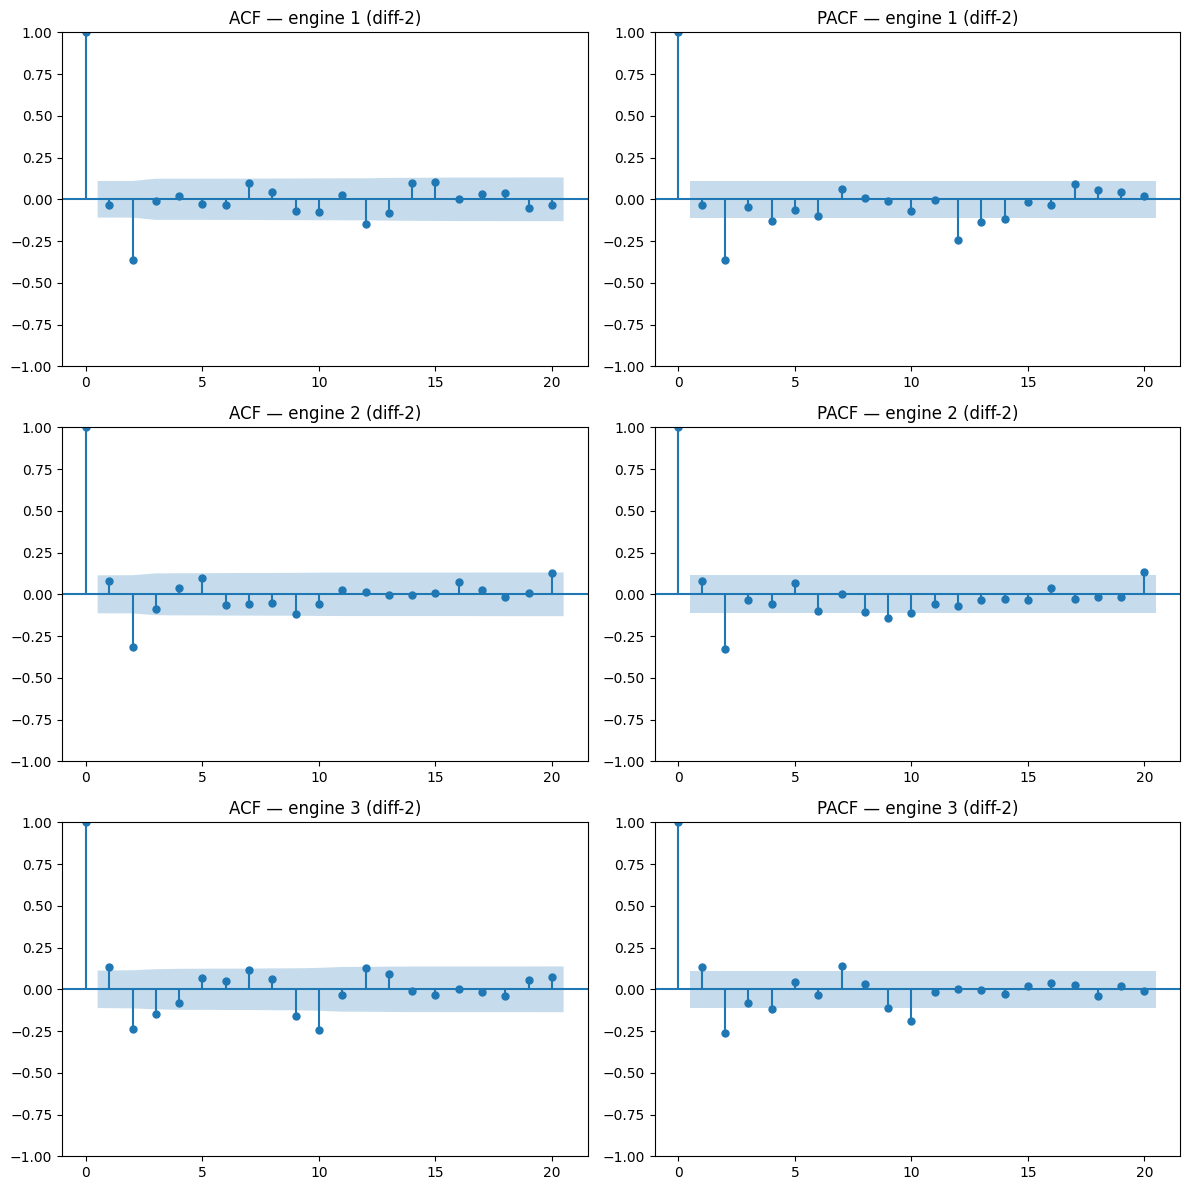

In [6]:
plot_acf_pacf_multi(train, d=MODAL_D, n_engines=3, lags=20)

## 5. `optimize_ARIMA` — select (p,q) by AIC (CH07 core step)

Exact copy of CH07 `optimize_ARIMA` function. d is fixed from ADF above.

In [7]:
BEST_P, BEST_Q = select_best_arima_order(train, d=MODAL_D, n_engines=15)

  engine 1: best (p,q)=(2, 3)  (AIC=-1758.02)
  engine 2: best (p,q)=(1, 2)  (AIC=-1844.76)
  engine 3: best (p,q)=(3, 2)  (AIC=-1800.73)
  engine 4: best (p,q)=(1, 2)  (AIC=-1418.15)
  engine 5: best (p,q)=(2, 2)  (AIC=-1054.77)
  engine 6: best (p,q)=(3, 3)  (AIC=-1810.7)
  engine 7: best (p,q)=(2, 1)  (AIC=-1242.4)
  engine 8: best (p,q)=(3, 2)  (AIC=-1350.05)
  engine 9: best (p,q)=(1, 2)  (AIC=-1877.11)
  engine 10: best (p,q)=(3, 3)  (AIC=-1766.67)
  engine 11: best (p,q)=(2, 1)  (AIC=-1834.98)
  engine 12: best (p,q)=(2, 3)  (AIC=-1195.26)
  engine 13: best (p,q)=(1, 1)  (AIC=-1429.72)
  engine 14: best (p,q)=(1, 2)  (AIC=-1363.61)
  engine 15: best (p,q)=(2, 2)  (AIC=-1176.51)

→ Modal best ARIMA order: (1,2,2)  (from 15 engines, freq=[((1, 2), 4), ((2, 3), 2), ((3, 2), 2), ((2, 2), 2), ((3, 3), 2)])


## 6. Fit best ARIMA + Ljung-Box + QQ plot (CH07 requirement)

CH07 adds QQ plot on top of Ljung-Box (CH06 had only Ljung-Box).

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   50
Model:               SARIMAX(1, 2, 2)   Log Likelihood                 122.128
Date:                Wed, 29 Apr 2026   AIC                           -236.257
Time:                        16:56:32   BIC                           -228.772
Sample:                             0   HQIC                          -233.428
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1093      0.252      0.434      0.665      -0.385       0.604
ma.L1          0.0388      0.229      0.170      0.865      -0.409       0.487
ma.L2         -0.9178      0.203     -4.530      0.0

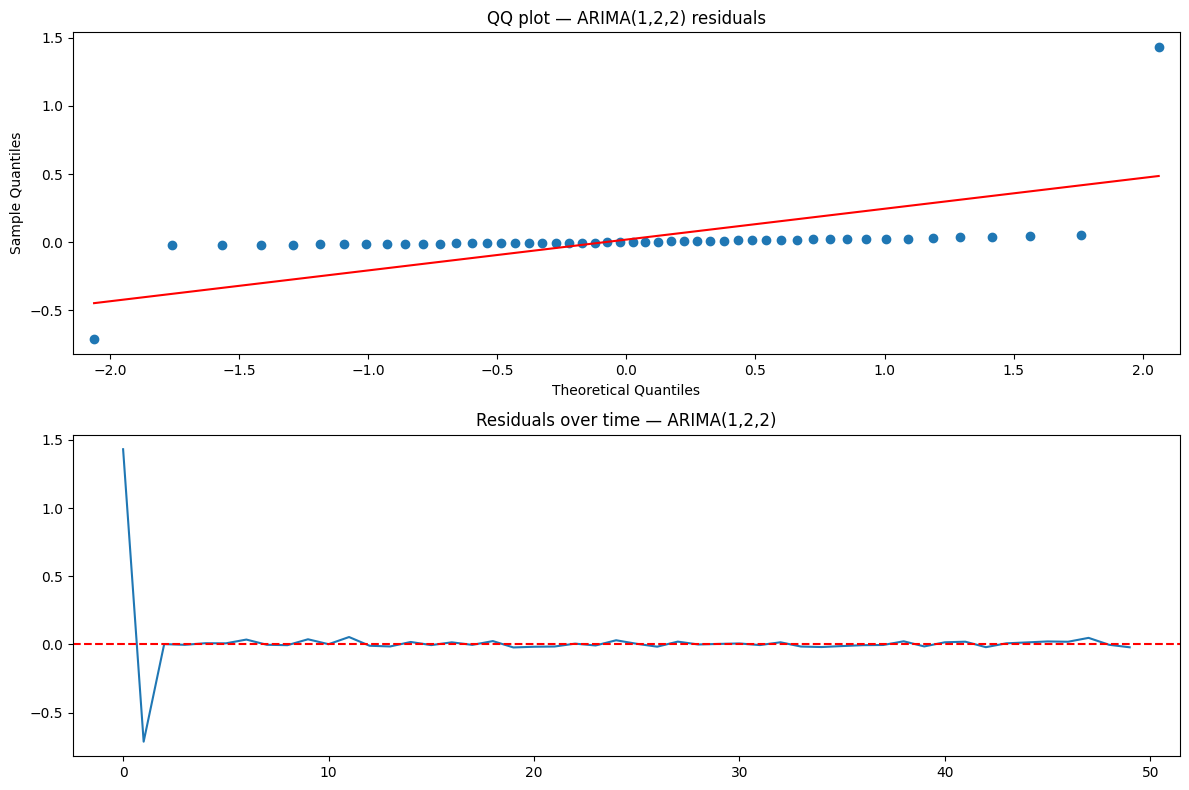

In [8]:
from src.models.classical import RECENT_WINDOW
fit_series = rep_smth[-RECENT_WINDOW:] if len(rep_smth) > RECENT_WINDOW else rep_smth
# WHY: fit on recent window only — early stable cycles dominate and bias slope toward zero
model_fit = SARIMAX(fit_series, order=(BEST_P, MODAL_D, BEST_Q),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(
    model_fit.resid,
    model_name=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})",
    plot_qq=True,
)

## 7. Forecast trajectory demo (CH07 style)

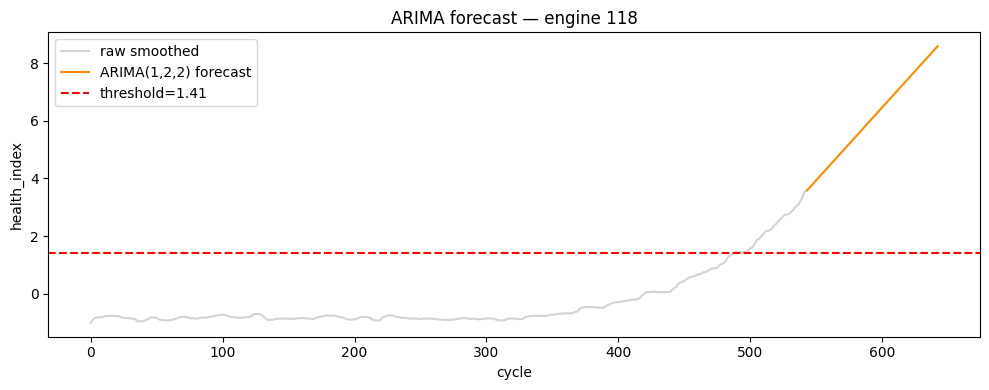

In [9]:
fcst = model_fit.forecast(steps=100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(rep_smth)), rep_smth, color="lightgray", label="raw smoothed")
ax.plot(range(len(rep_smth), len(rep_smth) + len(fcst)), fcst,
        color="darkorange", label=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q}) forecast")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"ARIMA forecast — engine {rep_eid}")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Rolling forecast — walk-forward (CH07 pattern)

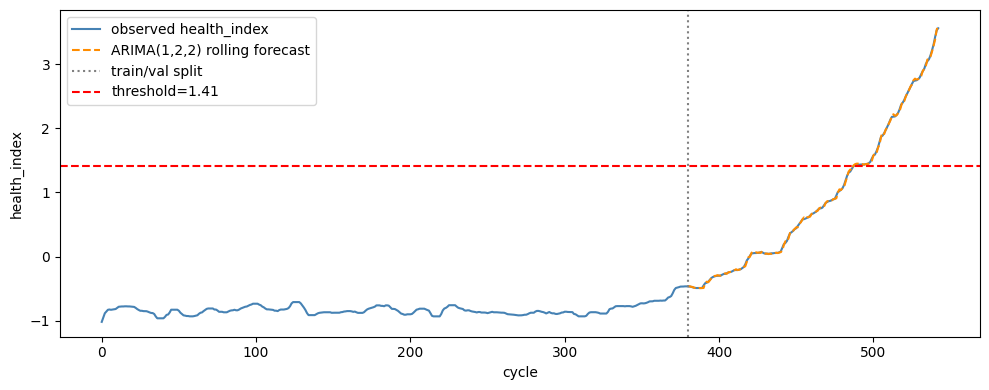

Rolling forecast RMSE: 0.0160


In [10]:
TRAIN_LEN = int(len(rep_smth) * 0.7)
WINDOW    = 1

pred_arima = rolling_forecast_engine(
    series=rep_smth, train_len=TRAIN_LEN, order=(BEST_P, MODAL_D, BEST_Q), window=WINDOW,
)
actual_val = rep_smth[TRAIN_LEN: TRAIN_LEN + len(pred_arima)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rep_smth, color="steelblue", label="observed health_index")
ax.plot(range(TRAIN_LEN, TRAIN_LEN + len(pred_arima)), pred_arima,
        color="darkorange", ls="--", label=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q}) rolling forecast")
ax.axvline(TRAIN_LEN, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.legend(); plt.tight_layout(); plt.show()

rmse_roll = float(np.sqrt(np.mean((actual_val - pred_arima)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 9. Full test-set evaluation

In [11]:
predict_fn = partial(predict_rul_arima, p=BEST_P, d=MODAL_D, q=BEST_Q)
y_true, y_pred = predict_dataset(test, predict_fn, THRESHOLD, verbose_engines=True)
evaluate(y_true, y_pred, model_name=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})")

    engine    1  true=  22.0  pred=  18.5  err=-3.5
    engine    2  true=  39.0  pred=  32.6  err=-6.4
    engine    3  true= 107.0  pred=  96.7  err=-10.3
    engine    4  true=  75.0  pred=  97.3  err=+22.3
    engine    5  true= 125.0  pred=  69.6  err=-55.4
    engine    6  true=  78.0  pred=  96.1  err=+18.1
    engine    7  true=  94.0  pred= 110.0  err=+16.0
    engine    8  true=  14.0  pred=   2.6  err=-11.4
    engine    9  true=  99.0  pred=  95.1  err=-3.9
    engine   10  true= 125.0  pred=  98.3  err=-26.7
    engine   11  true= 125.0  pred=  94.4  err=-30.6
    engine   12  true=   7.0  pred=   2.6  err=-4.4
    engine   13  true=  71.0  pred= 110.0  err=+39.0
    engine   14  true= 105.0  pred=  73.8  err=-31.2
    engine   15  true=  12.0  pred=   2.6  err=-9.4
    engine   16  true= 125.0  pred=  94.0  err=-31.0
    engine   17  true= 125.0  pred= 110.0  err=-15.0
    engine   18  true= 104.0  pred=  81.4  err=-22.6
    engine   19  true= 125.0  pred=  97.2  err=-27.

{'rmse': 31.09507179260254,
 'nasa_score': 29736.3046875,
 'nasa_score_mean': 119.90445438508064,
 'r2_score': 0.4766080379486084,
 'bias': -15.697816848754883}

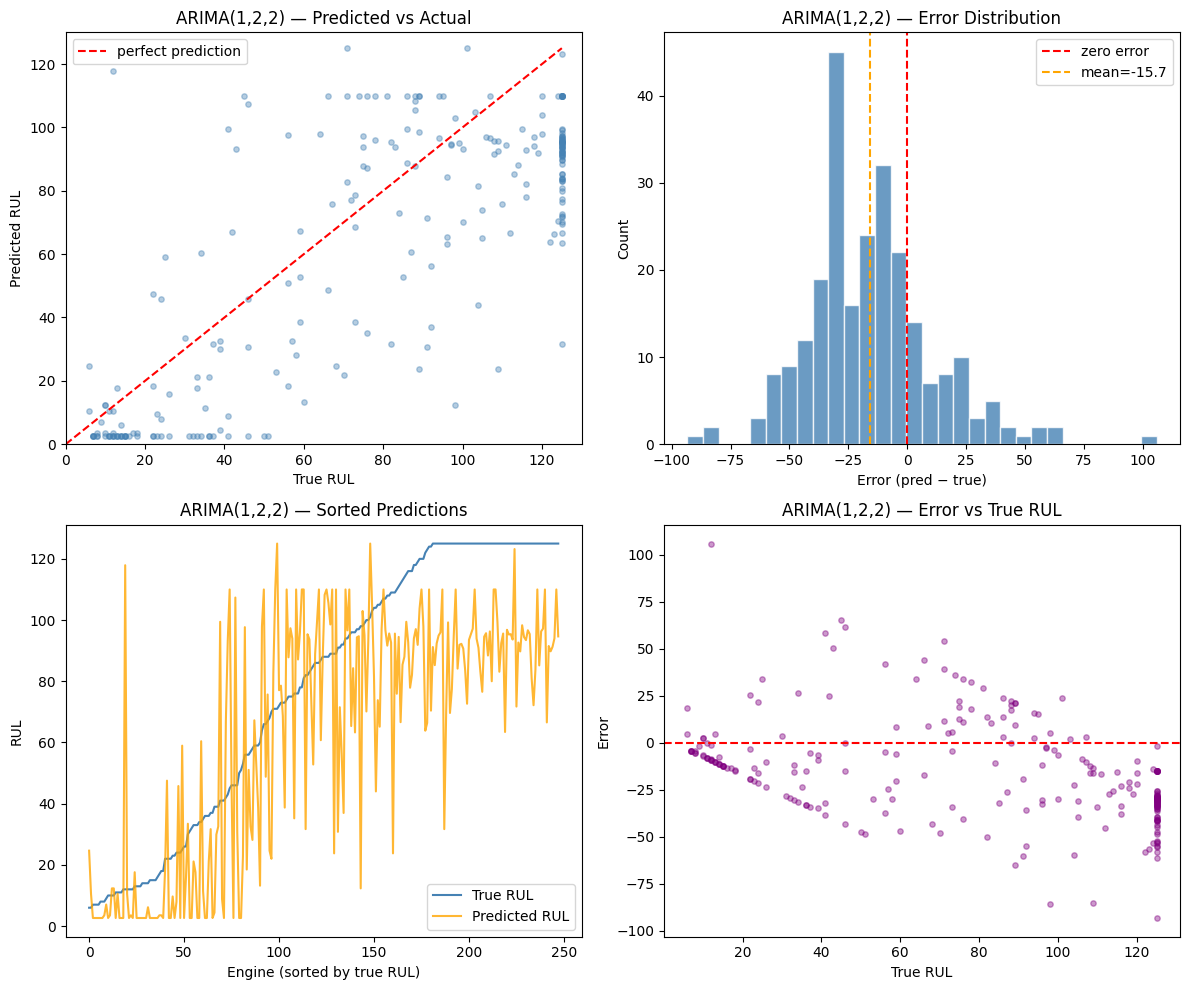

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_predictions(y_true, y_pred, model_name="Model"):
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    # ── Plot 1: Predicted vs Actual ───────────────────────────
    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.4, color="steelblue", s=15)
    ax.plot([0, 125], [0, 125], 'r--', lw=1.5, label="perfect prediction")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{model_name} — Predicted vs Actual")
    ax.legend()
    ax.set_xlim(0, 130); ax.set_ylim(0, 130)

    # ── Plot 2: Error distribution ────────────────────────────
    ax = axes[1]
    errors = y_pred - y_true
    ax.hist(errors, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", ls="--", lw=1.5, label="zero error")
    ax.axvline(errors.mean(), color="orange", ls="--", lw=1.5,
            label=f"mean={errors.mean():.1f}")
    ax.set_xlabel("Error (pred − true)")
    ax.set_ylabel("Count")
    ax.set_title(f"{model_name} — Error Distribution")
    ax.legend()

    # ── Plot 3: Sorted predictions ────────────────────────────
    ax = axes[2]
    sort_idx = np.argsort(y_true)
    ax.plot(y_true[sort_idx], color="steelblue", label="True RUL", lw=1.5)
    ax.plot(y_pred[sort_idx], color="orange", label="Predicted RUL", lw=1.5, alpha=0.8)
    ax.set_xlabel("Engine (sorted by true RUL)")
    ax.set_ylabel("RUL")
    ax.set_title(f"{model_name} — Sorted Predictions")
    ax.legend()

    # ── Plot 4: Residuals vs True RUL (VERY IMPORTANT) ────────
    ax = axes[3]
    ax.scatter(y_true, errors, alpha=0.4, s=15, color="purple")
    ax.axhline(0, color="red", ls="--")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Error")
    ax.set_title(f"{model_name} — Error vs True RUL")

    plt.tight_layout()
    plt.show()
# ── Call for each model ───────────────────────────────────────────────
# In T09: plot_predictions(y_true, y_pred, model_name=f"ARMA({BEST_P},{BEST_Q})")
plot_predictions(y_true, y_pred, model_name=f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})")

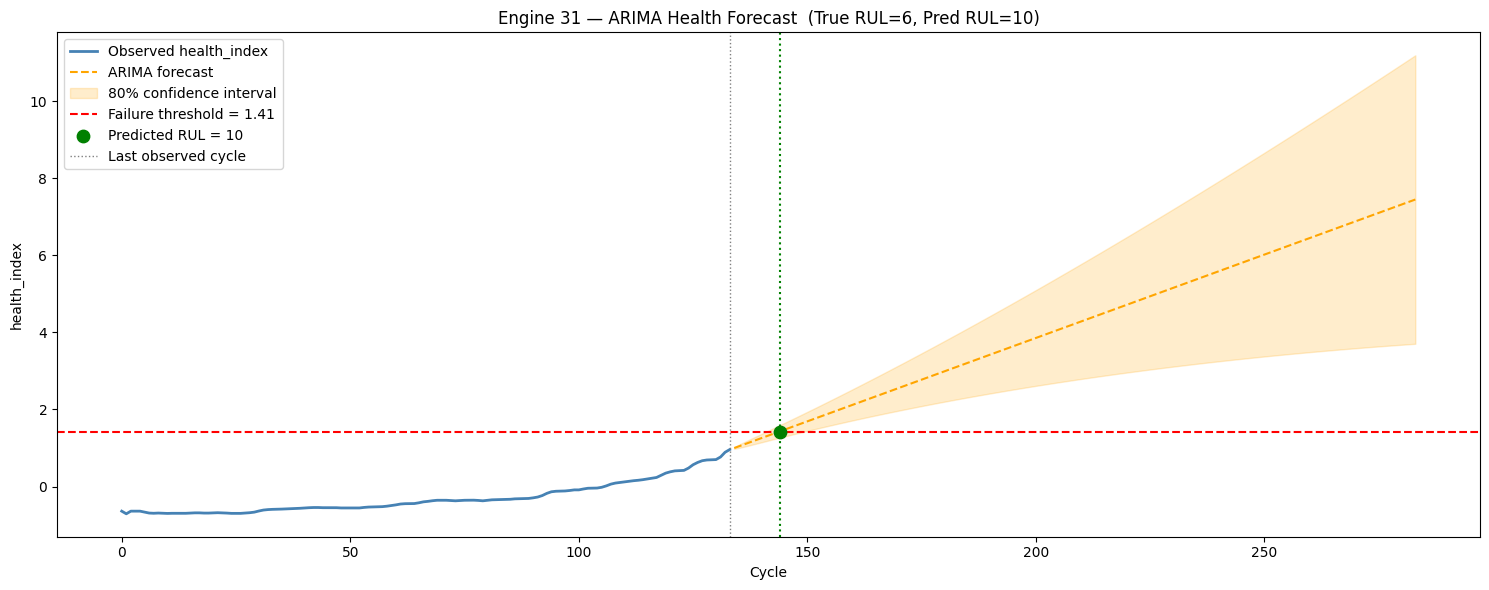

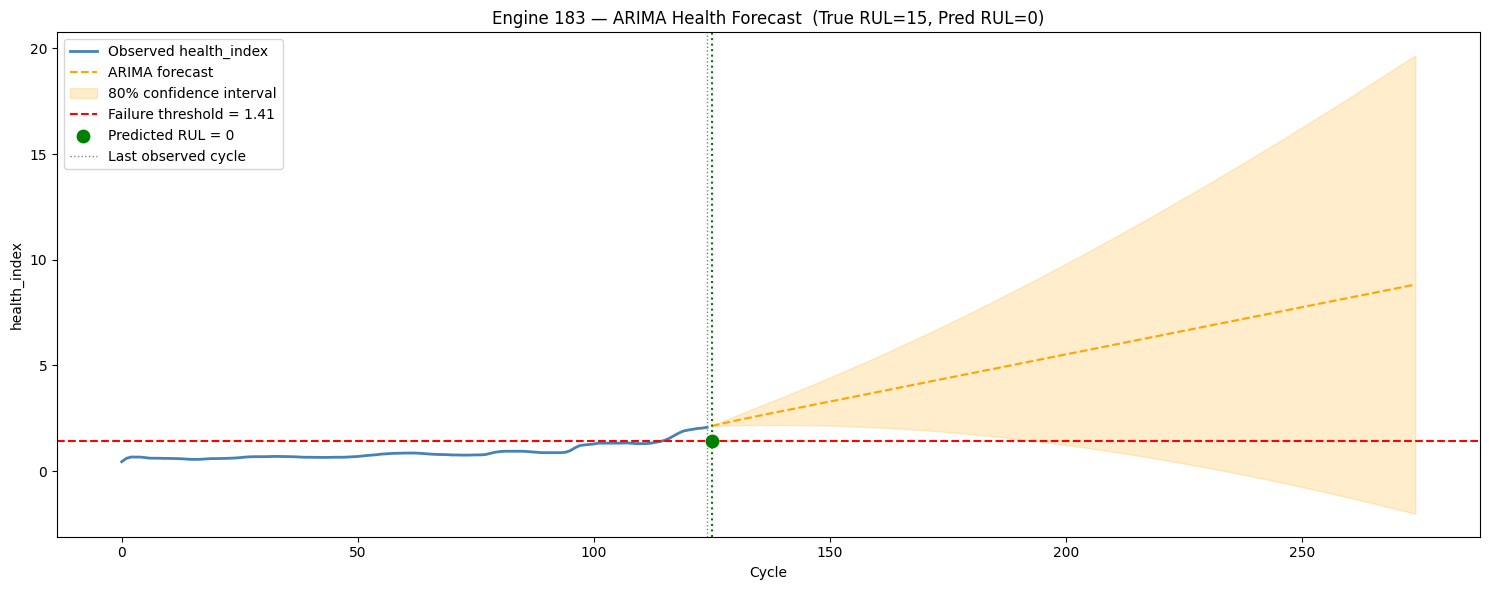

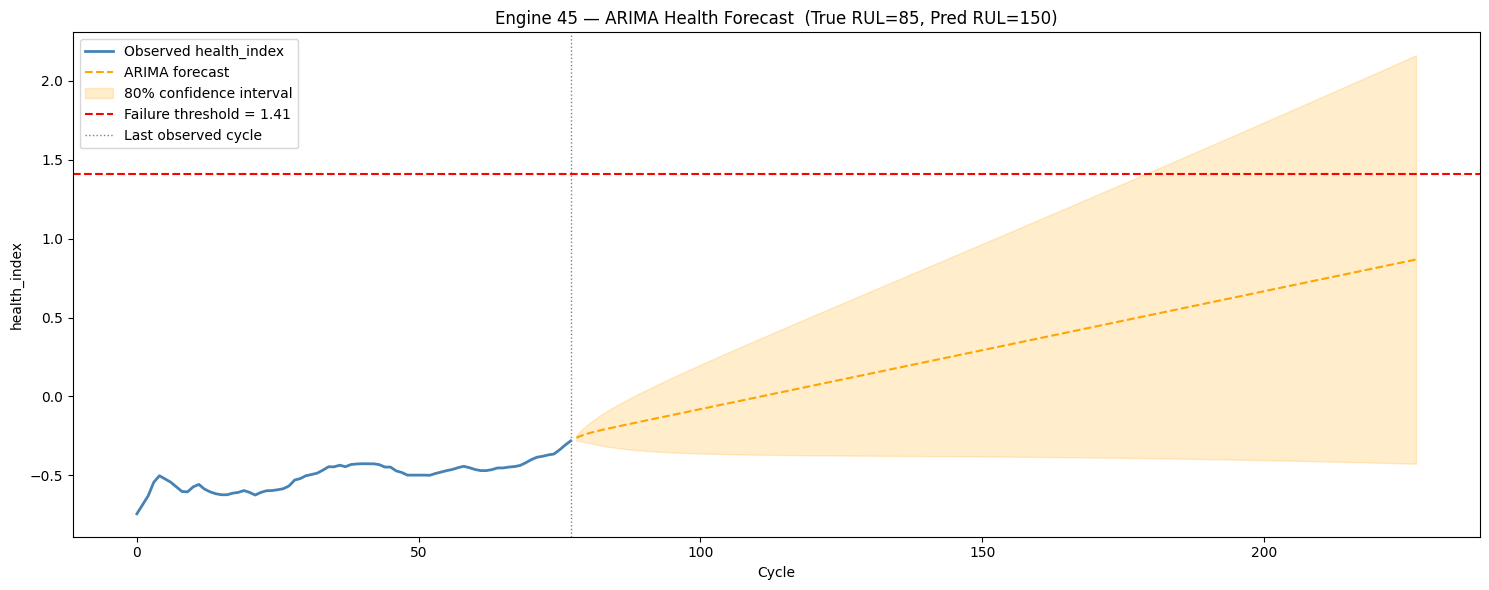

In [13]:
def plot_health_forecast(
    train: pd.DataFrame,
    test: pd.DataFrame,
    engine_id: int,
    predict_order: tuple,        # (p, d, q)
    threshold: float,
    model_name: str = "ARIMA",
    max_horizon: int = 150,
):
    """
    For one engine:
      - Blue  = observed health_index history (from test)
      - Orange = forecast from last observed point
      - Red dashed = failure threshold
      - Green dot  = predicted failure (threshold crossing)
    """
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # ── Get engine history ────────────────────────────────────────────
    eng   = test[test["engine_id"] == engine_id].sort_values("cycle")
    raw   = eng["health_index"].values
    true_rul = float(eng["RUL"].iloc[-1])

    # smooth exactly as predict_rul_* does
    series = smooth_series(raw)

    p, d, q = predict_order

    
    # ── Fit and forecast ──────────────────────────────────────────────
    res          = SARIMAX(series, order=(p, d, q),
                           simple_differencing=False).fit(disp=False)

    forecast_obj = res.get_forecast(steps=max_horizon)
    fcst_mean    = forecast_obj.predicted_mean
    fcst_ci      = forecast_obj.conf_int(alpha=0.2)

    # WHY: ARIMA point forecast is always smooth — it's the expected value.
    # To show realistic fluctuation, add noise sampled from model residuals.
    # This is statistically valid — residuals = unexplained variation the
    # model learned from. One noisy path = one plausible future scenario.
    np.random.seed(42)
    resid_std  = float(np.std(res.resid))
    noise      = np.random.normal(0, resid_std, size=len(fcst_mean))
    fcst_noisy = fcst_mean # + nosie # fluctuating forecast path

    # threshold crossing on MEAN (not noisy) — keeps RUL prediction stable
    crossings = np.where(fcst_mean >= threshold)[0]
    pred_rul  = int(crossings[0]) if crossings.size > 0 else max_horizon

    # ── Build x-axes ─────────────────────────────────────────────────
    obs_x  = np.arange(len(series))
    fcst_x = np.arange(len(series), len(series) + len(fcst_mean))

    # ── Plot ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 6))

    ax.plot(obs_x,     series,     color="steelblue", lw=2,
            label="Observed health_index")

    # noisy line for visual realism
    ax.plot(fcst_x,    fcst_noisy, color="orange",    lw=1.5, ls="--",
            label=f"{model_name} forecast")

    # confidence band around the MEAN (not noisy line)
    ax.fill_between(fcst_x,
                    fcst_ci[:, 0],
                    fcst_ci[:, 1],
                    color="orange", alpha=0.2,
                    label="80% confidence interval")

    ax.axhline(threshold, color="red", ls="--", lw=1.5,
               label=f"Failure threshold = {threshold:.2f}")

    if crossings.size > 0:
        cross_x = len(series) + pred_rul
        ax.axvline(cross_x, color="green", ls=":", lw=1.5)
        ax.scatter([cross_x], [threshold], color="green", zorder=5, s=80,
                   label=f"Predicted RUL = {pred_rul}")

    ax.axvline(len(series) - 1, color="gray", ls=":", lw=1,
               label="Last observed cycle")

    ax.set_xlabel("Cycle")
    ax.set_ylabel("health_index")
    ax.set_title(f"Engine {engine_id} — {model_name} Health Forecast  "
                 f"(True RUL={true_rul:.0f}, Pred RUL={pred_rul})")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
  


# ── Pick a few interesting engines to show ────────────────────────────
# Good prediction
plot_health_forecast(train, test, engine_id=31,
                     predict_order=(BEST_P, MODAL_D, BEST_Q),
                     threshold=THRESHOLD, model_name=f"ARIMA")

# Bad prediction (outlier) — shows why NASA score blows up
plot_health_forecast(train, test, engine_id=183,
                     predict_order=(BEST_P, MODAL_D, BEST_Q),
                     threshold=THRESHOLD, model_name=f"ARIMA")

# Mid-range engine
plot_health_forecast(train, test, engine_id=45,
                     predict_order=(BEST_P, MODAL_D, BEST_Q),
                     threshold=THRESHOLD, model_name=f"ARIMA")

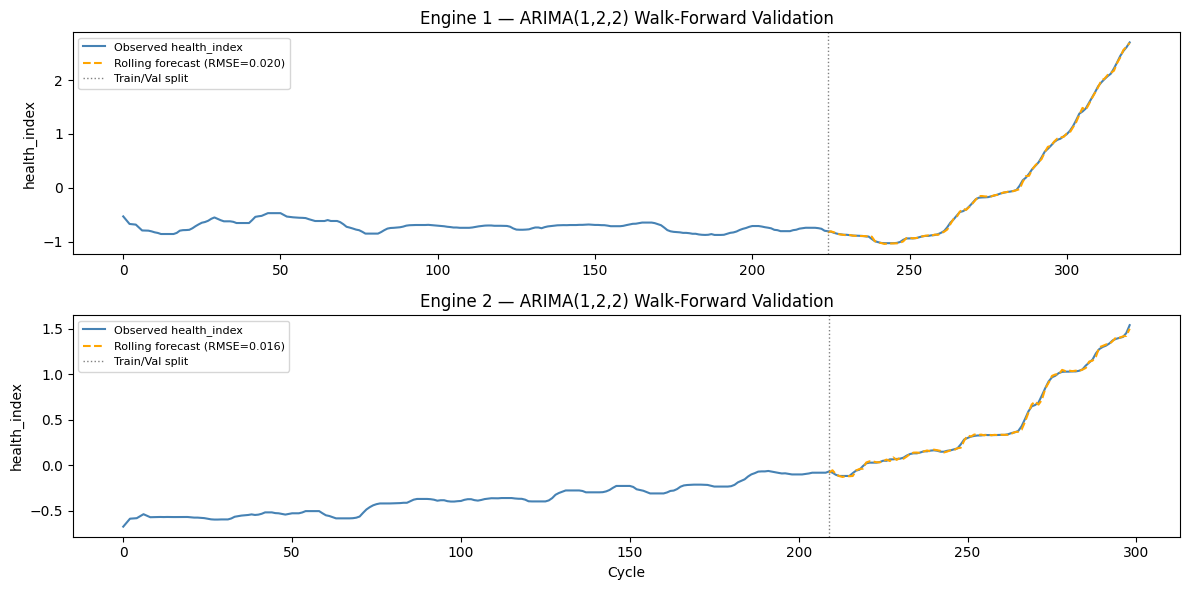


ARIMA(1,2,2) Walk-Forward Validation Summary
Engines validated : 2
Mean RMSE         : 0.0180
Std RMSE          : 0.0019
Best engine RMSE  : 0.0161
Worst engine RMSE : 0.0200


In [14]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, BEST_Q),
    n_engines  = 2,
    model_name = f"ARIMA({BEST_P},{MODAL_D},{BEST_Q})"
)

## Save Results to CSV

In [15]:
from src.evaluation.metrics import save_model_results

save_model_results(
    model_name = f'ARIMA({BEST_P},{MODAL_D},{BEST_Q})',
    model_type = 'classical',
    y_true     = y_true,
    y_pred     = y_pred,
)

  [ARIMA(1,2,2)] RMSE: 31.0951  |  NASA Score: 29736.30 (mean: 119.90)  |  R2: 0.4766  |  Bias: -15.70 (early ↓)
  → Saved to results/all_model_results.csv


{'rmse': 31.09507179260254,
 'nasa_score': 29736.3046875,
 'nasa_score_mean': 119.90445438508064,
 'r2_score': 0.4766080379486084,
 'bias': -15.697816848754883}